## 0. Setup

In [6]:
INDIA_PROJECTED_CRS = "24378"

In [7]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# general
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from tqdm.notebook import tqdm

from os import listdir

# for plotting and coloring
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math
import matplotlib.cm

# for handling S2 cells and downloading VIDA data
import boto3
from s2cell.s2cell import lat_lon_to_cell_id
import s2sphere
from shapely.geometry import Polygon

gpd.options.io_engine = "pyogrio"

In [9]:
from gridsample.utils import create_ids, create_gmap_links, save_shapefiles

In [10]:
from utils import (
    download_VIDA_rooftops_data_by_s2,
    generate_colormap,
    get_matched_rooftop_centroids_from_s2_file,
    get_s2_cell_ids,
    s2_cell_ids_to_shapes_gdf,
)

In [11]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_panel"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data" # symlinked from IFS folder
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs" / "training_phase_3_v1"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs" / "training_phase_3_v1"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load Pilot Boundaries

In [12]:
# get all filepaths that end in `kml` inside the folder
boundaries_dir = RAW_DATA_DIR / "99. Side Quest Data" / "Panel" / "Phase 3 Training"
all_files = list(boundaries_dir.glob("**/*.kml"))
all_files = [f for f in all_files if f.is_file()]

# load all shapes into one gdf
gdf_list = []
for filepath in all_files:
    temp_gdf = gpd.read_file(filepath)
    temp_gdf["State Name"] = filepath.stem
    gdf_list.append(temp_gdf)
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

In [13]:
gdf

,Name,Description,geometry,State Name
0,"Mandi Mohalla, Meena Bazar",,"POLYGON Z ((76.65548 12.32276 0.00000, 76.6554...",Karnataka
1,Halladakeri,,"POLYGON Z ((76.65360 12.31421 0.00000, 76.6529...",Karnataka
2,"Shantinagara North, Rajiv Nagar, Mysuru",,"POLYGON Z ((76.68367 12.32996 0.00000, 76.6823...",Karnataka
3,Udayagiri,,"POLYGON Z ((76.67779 12.32120 0.00000, 76.6760...",Karnataka
4,"Shantinagara North, Udayagiri",,"POLYGON Z ((76.68217 12.32440 0.00000, 76.6813...",Karnataka
5,Udayagiri,,"POLYGON Z ((76.67810 12.31981 0.00000, 76.6802...",Karnataka
6,Mayapuri,,"POLYGON Z ((90.56115 26.46830 0.00000, 90.5666...",Assam
7,Sahid Vedi,,"POLYGON Z ((90.55705 26.45881 0.00000, 90.5566...",Assam
8,Rolling Mill,,"POLYGON Z ((90.55204 26.49922 0.00000, 90.5514...",Assam
9,New Bongaigaon,,"POLYGON Z ((90.53755 26.47716 0.00000, 90.5387...",Assam


In [15]:
# change polygons to 2d polygons
# gdf = gdf.set_geometry(gdf.geometry.apply(lambda geom: geom2d(geom)))

#### Add unique ID column

In [16]:
gdf["Unique Shape ID"] = create_ids(len(gdf), "SHAPE_")
gdf

,Name,Description,geometry,State Name,Unique Shape ID
0,"Mandi Mohalla, Meena Bazar",,"POLYGON Z ((76.65548 12.32276 0.00000, 76.6554...",Karnataka,SHAPE_01
1,Halladakeri,,"POLYGON Z ((76.65360 12.31421 0.00000, 76.6529...",Karnataka,SHAPE_02
2,"Shantinagara North, Rajiv Nagar, Mysuru",,"POLYGON Z ((76.68367 12.32996 0.00000, 76.6823...",Karnataka,SHAPE_03
3,Udayagiri,,"POLYGON Z ((76.67779 12.32120 0.00000, 76.6760...",Karnataka,SHAPE_04
4,"Shantinagara North, Udayagiri",,"POLYGON Z ((76.68217 12.32440 0.00000, 76.6813...",Karnataka,SHAPE_05
5,Udayagiri,,"POLYGON Z ((76.67810 12.31981 0.00000, 76.6802...",Karnataka,SHAPE_06
6,Mayapuri,,"POLYGON Z ((90.56115 26.46830 0.00000, 90.5666...",Assam,SHAPE_07
7,Sahid Vedi,,"POLYGON Z ((90.55705 26.45881 0.00000, 90.5566...",Assam,SHAPE_08
8,Rolling Mill,,"POLYGON Z ((90.55204 26.49922 0.00000, 90.5514...",Assam,SHAPE_09
9,New Bongaigaon,,"POLYGON Z ((90.53755 26.47716 0.00000, 90.5387...",Assam,SHAPE_10


## 5. Download rooftops

#### Identify S2 cell IDs

In [17]:
s2_cell_ids = get_s2_cell_ids(gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 0


/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:126: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


4

#### Check if identified cells cover all areas of interest

In [18]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [19]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


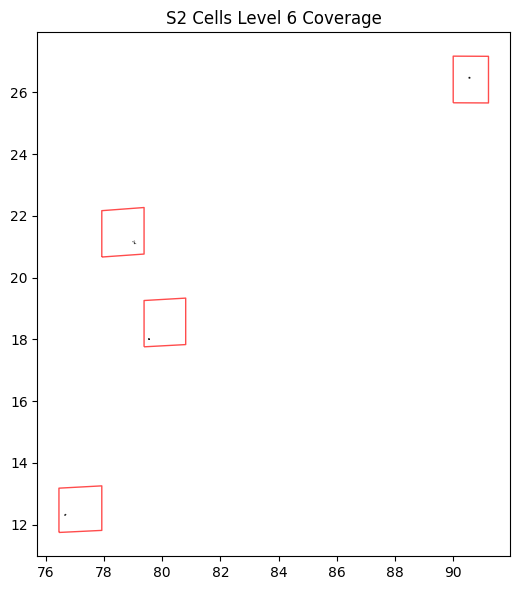

In [20]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

#### Download the S2 cells

In [22]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4300656169162113024 already exists.
File 3988218945013284864 already exists.
File 4311352218277117952 already exists.
File 4193695678012063744 downloaded.


## 6. Load rooftops and match to areas

In [23]:
# Get matched rooftops for each S2 cell
matched_rooftop_centroids_gdf_list = []
for s2_cell_id in tqdm(s2_cell_ids):
    matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
        s2_file_dir=RAW_DATA_DIR / "02. Rooftop Data",
        s2_cell_id=s2_cell_id,
        boundaries_gdf=gdf,
    )
    matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
matched_rooftop_centroids_gdf = pd.concat(
    matched_rooftop_centroids_gdf_list, ignore_index=True
)

# Save the matched rooftops data
save_shapefiles(
    matched_rooftop_centroids_gdf,
    CLEANED_DATA_DIR / "01. Matched Rooftop Data",
    "matched_rooftops",
    ["parquet"],
)

  0%|          | 0/4 [00:00<?, ?it/s]

/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid
/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results fro

In [24]:
# ax = matched_rooftop_centroids_gdf.sample(1000).plot(
#     cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
# )
# gdf.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [25]:
matched_rooftops_gdf = gpd.read_parquet(CLEANED_DATA_DIR / "01. Matched Rooftop Data" / "matched_rooftops.parquet")

In [26]:
len(matched_rooftops_gdf)

8088

In [28]:
no_rooftop_PSU_IDs = set(gdf["Unique Shape ID"].unique()).difference(
    set(matched_rooftops_gdf["Unique Shape ID"].unique())
)
no_rooftop_PSU_gdf = gdf[gdf["Unique Shape ID"].isin(no_rooftop_PSU_IDs)]
no_rooftop_PSU_gdf

,Name,Description,geometry,State Name,Unique Shape ID


In [29]:
# save_shapefiles(
#     no_rooftop_PSU_gdf,
#     OUTPUT_DATA_DIR / "Sampled PSUs",
#     "PSUs_with_no_rooftops",
#     ["csv", "kml"],
# )

## 8. Sample rooftops

### Do the sampling

In [72]:
# Define the base number of rooftops per shape
ROOFTOPS_PER_SHAPE = 75

sampled_rooftops = matched_rooftops_gdf.groupby(
    "Unique Shape ID", group_keys=False
).apply(lambda x: x.sample(n=min(ROOFTOPS_PER_SHAPE, x.shape[0]), random_state=42))

In [73]:
# check if we have the right number of rooftops overall
len(gdf) == (len(sampled_rooftops) / ROOFTOPS_PER_SHAPE)

False

In [74]:
# one shape only has 56 pins
sampled_rooftops["Unique Shape ID"].value_counts()

Unique Shape ID
SHAPE_01    75
SHAPE_02    75
SHAPE_21    75
SHAPE_20    75
SHAPE_19    75
SHAPE_18    75
SHAPE_17    75
SHAPE_15    75
SHAPE_14    75
SHAPE_13    75
SHAPE_12    75
SHAPE_11    75
SHAPE_10    75
SHAPE_09    75
SHAPE_08    75
SHAPE_07    75
SHAPE_06    75
SHAPE_05    75
SHAPE_04    75
SHAPE_03    75
SHAPE_22    75
SHAPE_16    56
Name: count, dtype: int64

<Axes: >

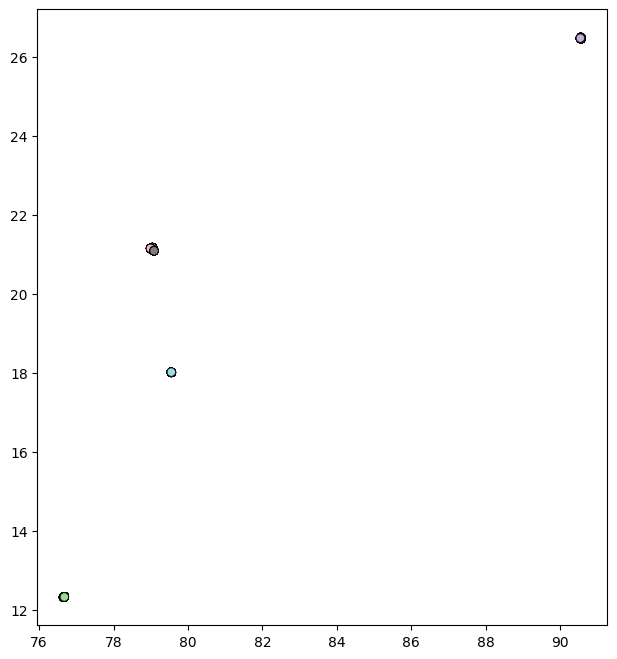

In [75]:
sampled_rooftops.plot(
    figsize=(8, 8),
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [76]:
# Rooftop number within each shape
sampled_rooftops["Rooftop ID Per Shape"] = (
    sampled_rooftops.groupby("Unique Shape ID").cumcount() + 1
)

sampled_rooftops["Rooftop ID Per State"] = (
    sampled_rooftops.groupby("State Name").cumcount() + 1
)

sampled_rooftops["Unique Rooftop ID"] = sampled_rooftops.apply(
    lambda row: f"{row['State Name'].replace(' ', '_')}_{row['Unique Shape ID']}_ROOFTOP_{row['Rooftop ID Per Shape']}",
    axis=1,
)

In [77]:
sampled_rooftops

,boundary_id,bf_source,confidence,area_in_meters,s2_id,country_iso,geometry,geohash,bbox,Name,Description,State Name,Unique Shape ID,s2_rooftop_id,Rooftop ID Per Shape,Rooftop ID Per State,Unique Rooftop ID
598,56,google,0.7269,154.0711,4300656169162113024,IND,POINT (76.65599 12.32265),tdnw0770,"{'xmax': 76.6560420985554, 'xmin': 76.65593719...","Mandi Mohalla, Meena Bazar",,Karnataka,SHAPE_01,S2_4300656169162113024_ROOFTOP_0599,1,1,Karnataka_SHAPE_01_ROOFTOP_1
522,56,google,0.7273,30.2769,4300656169162113024,IND,POINT (76.65567 12.32175),tdnw074g,"{'xmax': 76.6556936529795, 'xmin': 76.65563752...","Mandi Mohalla, Meena Bazar",,Karnataka,SHAPE_01,S2_4300656169162113024_ROOFTOP_0523,2,2,Karnataka_SHAPE_01_ROOFTOP_2
548,56,google,0.7196,98.6558,4300656169162113024,IND,POINT (76.65596 12.32208),tdnw075j,"{'xmax': 76.65603409114101, 'xmin': 76.6558882...","Mandi Mohalla, Meena Bazar",,Karnataka,SHAPE_01,S2_4300656169162113024_ROOFTOP_0549,3,3,Karnataka_SHAPE_01_ROOFTOP_3
544,56,google,0.7750,115.0945,4300656169162113024,IND,POINT (76.65589 12.32190),tdnw075h,"{'xmax': 76.6559381866613, 'xmin': 76.65584205...","Mandi Mohalla, Meena Bazar",,Karnataka,SHAPE_01,S2_4300656169162113024_ROOFTOP_0545,4,4,Karnataka_SHAPE_01_ROOFTOP_4
534,56,google,0.7591,387.0230,4300656169162113024,IND,POINT (76.65552 12.32249),tdnw074z,"{'xmax': 76.6556124347597, 'xmin': 76.65544269...","Mandi Mohalla, Meena Bazar",,Karnataka,SHAPE_01,S2_4300656169162113024_ROOFTOP_0535,5,5,Karnataka_SHAPE_01_ROOFTOP_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7324,56,google,0.9353,199.9512,4193695678012063744,IND,POINT (79.54945 18.01692),tg0w6pyh,"{'xmax': 79.5495009166254, 'xmin': 79.54939635...","Lashkar Singaram, Naim Nagar",,Telangana,SHAPE_22,S2_4193695678012063744_ROOFTOP_1269,71,446,Telangana_SHAPE_22_ROOFTOP_71
7244,56,google,0.6812,54.9680,4193695678012063744,IND,POINT (79.55164 18.01555),tg0w6pxs,"{'xmax': 79.5516818562551, 'xmin': 79.55160205...","Lashkar Singaram, Naim Nagar",,Telangana,SHAPE_22,S2_4193695678012063744_ROOFTOP_1189,72,447,Telangana_SHAPE_22_ROOFTOP_72
7305,56,google,0.7739,19.1448,4193695678012063744,IND,POINT (79.55038 18.01646),tg0w6pyc,"{'xmax': 79.5504002060401, 'xmin': 79.55035087...","Lashkar Singaram, Naim Nagar",,Telangana,SHAPE_22,S2_4193695678012063744_ROOFTOP_1250,73,448,Telangana_SHAPE_22_ROOFTOP_73
7378,56,google,0.6663,16.3667,4193695678012063744,IND,POINT (79.55099 18.01627),tg0w6pz2,"{'xmax': 79.5510073688336, 'xmin': 79.55096526...","Lashkar Singaram, Naim Nagar",,Telangana,SHAPE_22,S2_4193695678012063744_ROOFTOP_1323,74,449,Telangana_SHAPE_22_ROOFTOP_74


### Add gmap link

In [78]:
sampled_rooftops["latitude_original"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude_original"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link_original"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude_original",
    lon_name="longitude_original",
)

### Select only useful columns

In [79]:
sampled_rooftops.columns

Index(['boundary_id', 'bf_source', 'confidence', 'area_in_meters', 's2_id',
       'country_iso', 'geometry', 'geohash', 'bbox', 'Name', 'Description',
       'State Name', 'Unique Shape ID', 's2_rooftop_id',
       'Rooftop ID Per Shape', 'Rooftop ID Per State', 'Unique Rooftop ID',
       'latitude_original', 'longitude_original', 'gmap_link_original'],
      dtype='object')

In [80]:
chosen_cols = [
    "Unique Rooftop ID",
    "Unique Shape ID",
    "State Name",
    "Rooftop ID Per Shape",
    "latitude_original",
    "longitude_original",
    "gmap_link_original",
    "geometry",
    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [81]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [82]:
sampled_rooftops_organised_gdf

,Unique Rooftop ID,Unique Shape ID,State Name,Rooftop ID Per Shape,latitude_original,longitude_original,gmap_link_original,geometry
598,Karnataka_SHAPE_01_ROOFTOP_1,SHAPE_01,Karnataka,1,12.322645,76.655989,https://www.google.com/maps/search/?api=1&quer...,POINT (76.65599 12.32265)
522,Karnataka_SHAPE_01_ROOFTOP_2,SHAPE_01,Karnataka,2,12.321750,76.655666,https://www.google.com/maps/search/?api=1&quer...,POINT (76.65567 12.32175)
548,Karnataka_SHAPE_01_ROOFTOP_3,SHAPE_01,Karnataka,3,12.322081,76.655961,https://www.google.com/maps/search/?api=1&quer...,POINT (76.65596 12.32208)
544,Karnataka_SHAPE_01_ROOFTOP_4,SHAPE_01,Karnataka,4,12.321902,76.655890,https://www.google.com/maps/search/?api=1&quer...,POINT (76.65589 12.32190)
534,Karnataka_SHAPE_01_ROOFTOP_5,SHAPE_01,Karnataka,5,12.322493,76.655518,https://www.google.com/maps/search/?api=1&quer...,POINT (76.65552 12.32249)
...,...,...,...,...,...,...,...,...
7324,Telangana_SHAPE_22_ROOFTOP_71,SHAPE_22,Telangana,71,18.016922,79.549449,https://www.google.com/maps/search/?api=1&quer...,POINT (79.54945 18.01692)
7244,Telangana_SHAPE_22_ROOFTOP_72,SHAPE_22,Telangana,72,18.015554,79.551642,https://www.google.com/maps/search/?api=1&quer...,POINT (79.55164 18.01555)
7305,Telangana_SHAPE_22_ROOFTOP_73,SHAPE_22,Telangana,73,18.016459,79.550376,https://www.google.com/maps/search/?api=1&quer...,POINT (79.55038 18.01646)
7378,Telangana_SHAPE_22_ROOFTOP_74,SHAPE_22,Telangana,74,18.016265,79.550986,https://www.google.com/maps/search/?api=1&quer...,POINT (79.55099 18.01627)


### Save sampled data (original rooftop pins)

In [83]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "Full Sample",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 76.655988559814801.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'https://www.google.com/maps/search/?api=1&query=12.32264540299776,76.6559885598148' of field sampled_rooftops_centroids_original.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 76.655665589801899.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'h

## 9. Snap points to road

In [84]:
import yaml
from shapely import Point

from utils import get_nearest_points_on_road_batch, get_nearest_points_on_road_batch_parallel

In [85]:
# load API key
with open("../secrets/api_keys.yaml", "r") as f:
    config = yaml.safe_load(f)
    api_key = config["GOOGLE_ROADS_API_KEY"]

In [86]:
get_nearest_points_on_road_batch([Point(77.11432151622034, 28.677391409999522)], api_key)

[<POINT (77.114 28.677)>]

In [87]:
# test
get_nearest_points_on_road_batch(sampled_rooftops_organised_gdf.geometry.iloc[:5], api_key)

[<POINT (76.656 12.323)>,
 <POINT (76.656 12.322)>,
 <POINT (76.656 12.322)>,
 <POINT (76.656 12.322)>,
 <POINT (76.655 12.322)>]

In [88]:
get_nearest_points_on_road_batch_parallel(sampled_rooftops_organised_gdf.iloc[:150], api_key)

Snapping points to roads (batched):   0%|          | 0/2 [00:00<?, ?it/s]

598    POINT (76.65597 12.32272)
522    POINT (76.65566 12.32170)
548    POINT (76.65599 12.32208)
544    POINT (76.65600 12.32191)
534    POINT (76.65544 12.32250)
                 ...            
89     POINT (76.65473 12.31252)
245    POINT (76.65364 12.31373)
177    POINT (76.65364 12.31321)
33     POINT (76.65397 12.31231)
76     POINT (76.65465 12.31254)
Length: 150, dtype: geometry

#### Snap points to road

In [89]:
snapped_points_series = get_nearest_points_on_road_batch_parallel(
    sampled_rooftops_organised_gdf, api_key, max_workers=12
)
# took 1 second for 1,600 points (Panel)
# 30s for all 53,000 points 

Snapping points to roads (batched):   0%|          | 0/17 [00:00<?, ?it/s]

In [90]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = sampled_rooftops_snapped_gdf.index.map(snapped_points_series)

In [91]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

Geometry Type
Snapped to Road    1630
Original              1
Name: count, dtype: int64

#### Replace geometry to snapped one (missing filled in with original)

In [92]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [93]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

0

#### Update lat, lon, gmap_link

In [94]:
sampled_rooftops_snapped_gdf["latitude"] = list(sampled_rooftops_snapped_gdf.geometry.y)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [95]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        # IDs
        "Unique Rooftop ID",
        "Unique Shape ID",
        "State Name",
        "Rooftop ID Per Shape",
        "Geometry Type",
        # new points
        "geometry",
        "latitude",
        "longitude",
        "gmap_link",
        # original points
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "geometry_original",
    ]
]

#### Make lines between original and snapped points

In [96]:
from shapely.geometry import LineString

In [97]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [98]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

0

#### Save new files: snapped points, snapped lines

In [99]:
# Save CSV and parquet
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "Full Sample",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet"],
)

In [100]:
# Save KML
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
            # bad cols for KML
            "gmap_link_original",
            "gmap_link",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "Full Sample",
    "sampled_rooftops_snapped_points",
    ["kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 12.3227163.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 12.321704626907549.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 12.322078982977851.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_points.Rooftop I

In [101]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
sampled_rooftops_line_gdf = sampled_rooftops_line_gdf.drop(
    columns=["geometry_original", "geometry_line"]
)

In [102]:
save_shapefiles(
    sampled_rooftops_line_gdf.drop(
        # drop kml unfriendly columns
        columns=["gmap_link_original", "gmap_link"]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "Full Sample",
    "sampled_rooftops_snapped_lines",
    ["parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 12.3227163.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 12.321704626907549.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 12.322078982977851.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field sampled_rooftops_snapped_lines.Rooftop ID Pe

## Save per state

In [103]:
for state in tqdm(sampled_rooftops_organised_gdf["State Name"].unique()):
    state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / "State-Level" / state

    # save original points
    selected_state_original_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["State Name"] == state
    ]
    print(len(selected_state_original_gdf))

    save_shapefiles(
        selected_state_original_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_original_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["kml"],
    )

    # Save snapped points
    selected_state_snapped_gdf = sampled_rooftops_snapped_gdf[
        sampled_rooftops_snapped_gdf["State Name"] == state
    ].drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    )
    save_shapefiles(
        selected_state_snapped_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_snapped_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["kml"],
    )

    # Save lines
    selected_state_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
        sampled_rooftops_line_gdf["State Name"] == state
    ]
    save_shapefiles(
        selected_state_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["parquet", "kml"],
    )

  0%|          | 0/4 [00:00<?, ?it/s]

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Karnataka_sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 76.655988559814801.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Karnataka_sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 76.655665589801899.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Karnataka_sampled_rooftops_centroids_original.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 76.65596118022961.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning

450
300
431
450


/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Maharashtra_sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 21.174833761050408.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Maharashtra_sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 21.173897246338583.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field Maharashtra_sampled_rooftops_snapped_lines.Rooftop ID Per Shape: Lossy conversion occurred when trying to set 64 bit integer field from real value 21.174200049217461.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field 